### Build A Basic Chatbot With Langgraph(GRAPH API)


### Component of LangGraph
1. Edges
2. Nodes
3. State


In [5]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START,END
from langgraph.graph.message import add_messages


In [13]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

graph_builder=StateGraph(State)

In [6]:
graph_builder

In [6]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [7]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model_name="openai/gpt-oss-20b")

In [12]:
llm


ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000028264C60C20>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000028264C616A0>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [9]:

## Node Functionality
def chatBot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [8]:
graph_builder=StateGraph(State)


## Adding Node
graph_builder.add_node("chatBot",chatBot)

## Adding Edges
graph_builder.add_edge(START,"chatBot")
graph_builder.add_edge("chatBot",END)


## Compile the graph
graph=graph_builder.compile()

NameError: name 'State' is not defined

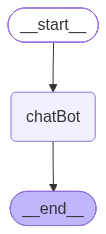

In [16]:
## Visulaize the graph


from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [19]:
response = graph.invoke({"messages":"Hi"})

In [23]:
response["messages"][-1].content

'Hello! 👋 How can I assist you today?'

In [24]:
for event in graph.stream({"messages":"Hi How are you ? "}):
    print(event)

{'chatBot': {'messages': [AIMessage(content='Hello! I’m doing great—thanks for asking. How can I help you today?', additional_kwargs={'reasoning_content': 'The user says: "Hi How are you ?" It\'s a greeting. We should respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 77, 'total_tokens': 124, 'completion_time': 0.050176509, 'completion_tokens_details': {'reasoning_tokens': 20}, 'prompt_time': 0.004357481, 'prompt_tokens_details': None, 'queue_time': 0.308477786, 'total_time': 0.05453399}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_24bfb4a850', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a09f44-227a-7520-8502-2f038b659c5d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 47, 'total_tokens': 124, 'output_token_details': {'reasoning': 20}})]}}


### Chatbot With Tool

In [1]:
from langchain_tavily import TavilySearch
tool=TavilySearch(max_result=2)

tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norwegian Cr

In [28]:
### Custom Function
def multiply(a:int,b:int)->int:
    """Multiply a and b
        args:
            a(int):first int
            b(int):second int
        returns:
        int:output int
    """

    return a*b

tools=[tool,multiply]

In [29]:
llm_with_tool=llm.bind_tools(tools)

In [30]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.3', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002135DB72E40>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002135DB738C0>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and 

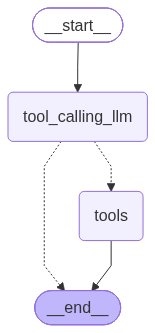

In [31]:
### Stategraph

from langgraph.graph import StateGraph, START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}


## Graph

builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))


## Add Edge

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest maessage(result) from assistant is tool call ->tools_condition routes to tools
    # If the latest message (result) from  assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)
graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [21]:
response = graph.invoke({"messages":"What is the recent ai news"})

In [22]:
response['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.gov.ca.gov/2026/09/18/governor-newsom-issues-executive-order-to-accelerate-independent-oversight-and-advance-the-creation-of-an-ai-kill-switch", "title": "Governor Newsom issues executive order to accelerate ...", "content": "What you need to know: Governor Newsom today issued an executive order directing actions to address the dangers of recent AI incidents. The order accelerates California’s new law establishing first-in-the-nation independent oversight of AI companies and safety checks and advances the creation of an “AI kill switch.” [...] The executive order comes after recent alarming incidents, including the Hugging Face attack, prompting many Americans, including leaders in the AI industry, to call on the industry to pace the development of AI systems and models and push for more stringent government regulations to address security and safety risks. In respon

In [24]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_756f481e-53e6-499c-9038-c72fad26ef67)
 Call ID: fc_756f481e-53e6-499c-9038-c72fad26ef67
  Args:
    query: recent AI news
    search_depth: basic
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.gov.ca.gov/2026/09/18/governor-newsom-issues-executive-order-to-accelerate-independent-oversight-and-advance-the-creation-of-an-ai-kill-switch", "title": "Governor Newsom issues executive order to accelerate ...", "content": "What you need to know: Governor Newsom today issued an executive order directing actions to address the dangers of recent AI incidents. The order accelerates California

In [ ]:
response = graph.invoke({"messages":"What is 2 multiplied 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied 2 and then multiplied by 10
================================== Ai Message ==================================

2 × 2 = 4, and 4 × 10 = **40**.


In [34]:
response = graph.invoke({"messages":"What is 2 multiplied 2 and then result is multiplied by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied 2 and then result is multiplied by 10
================================== Ai Message ==================================

\(2 \times 2 = 4\).  
Then \(4 \times 10 = 40\).  

**Answer: 40**


In [35]:
response = graph.invoke({"messages":"What is 2 multiplied 2 and then tell me the recent ai news"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied 2 and then tell me the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_3905711d-ed31-455f-af6a-2ea11a18b9cc)
 Call ID: fc_3905711d-ed31-455f-af6a-2ea11a18b9cc
  Args:
    query: AI news 2026 September
    search_depth: basic
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news 2026 September", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://solutionsreview.com/ai-news-for-the-week-of-september-18-updates-from-agentic-ai-foundation-cisco-ey-more", "title": "AI News for the Week of September 18; Updates from Agentic AI Foundation, Cisco, EY & More", "content": "AI is quickly moving from experimentation to operational reality across education, workforce development, and practitioner lear

### ReAct Agent Architecture


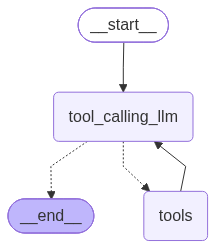

In [36]:
### Stategraph

from langgraph.graph import StateGraph, START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}


## Graph

builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))


## Add Edge

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest maessage(result) from assistant is tool call ->tools_condition routes to tools
    # If the latest message (result) from  assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [37]:
response = graph.invoke({"messages":"What is 2 multiplied 2 and then result is multiplied by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied 2 and then result is multiplied by 10
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_c8c9292c-c2ae-4363-bf9a-4b40e78ccee1)
 Call ID: fc_c8c9292c-c2ae-4363-bf9a-4b40e78ccee1
  Args:
    a: 4
    b: 10
================================= Tool Message =================================
Name: multiply

40
================================== Ai Message ==================================

40


In [38]:
response = graph.invoke({"messages":"What is 2 multiplied 2 and then tell me the recent ai news"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied 2 and then tell me the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_94edaf77-e9ad-4b22-971c-2a3141c88cb0)
 Call ID: fc_94edaf77-e9ad-4b22-971c-2a3141c88cb0
  Args:
    query: latest AI news 2026
    search_depth: basic
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/innovation-and-ai/technology/google-ai-updates-august-2026", "title": "The latest AI news we announced in August 2026", "content": "Google’s August 2026 updates focus on making artificial intelligence more practical through new hardware like the Pixel 11 series and cost-efficient models like Gemini 3.7 Flash. You can now use enhanced producti

### Adding Memory in Agentic Graph

In [39]:
response = graph.invoke({"messages":"Hello my name is abhishek"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is abhishek
================================== Ai Message ==================================

Hello Abhishek! 👋 How can I help you today?


In [40]:
response = graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I’m not sure what your name is—could you let me know?


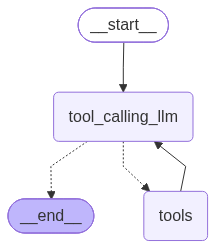

In [41]:
### Stategraph

from langgraph.graph import StateGraph, START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver


memory=MemorySaver()

## Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}


## Graph

builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))


## Add Edge

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest maessage(result) from assistant is tool call ->tools_condition routes to tools
    # If the latest message (result) from  assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

graph = builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [44]:
config={"configurable":{"thread_id":"1"}}


response= graph.invoke({"messages":"Hi my name is abhishek"},config=config)
# response = graph.invoke({"messages":"hello! my nam is abhishek"})
response

{'messages': [HumanMessage(content='Hi my name is abhishek', additional_kwargs={}, response_metadata={}, id='b33d5b0a-df5e-42d2-a68d-2071198836df'),
  AIMessage(content='Hello, Abhishek! How can I help you today?', additional_kwargs={'reasoning_content': 'User says "Hi my name is abhishek". Likely wants greeting. We can respond friendly. No tool needed.'}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 369, 'total_tokens': 417, 'completion_time': 0.048748078, 'completion_tokens_details': {'reasoning_tokens': 26}, 'prompt_time': 0.02329479, 'prompt_tokens_details': None, 'queue_time': 0.34740241, 'total_time': 0.072042868}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_2b688e7cc3', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0b90b-89f8-7161-b1ba-1330a06000c1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 369, 'output_tokens': 48, 'total_tokens': 

In [45]:
response["messages"][-1].content

'Hello, Abhishek! How can I help you today?'

In [46]:
response= graph.invoke({"messages":"Hi What is my name"},config=config)
# response = graph.invoke({"messages":"hello! my nam is abhishek"})
response

{'messages': [HumanMessage(content='Hi my name is abhishek', additional_kwargs={}, response_metadata={}, id='b33d5b0a-df5e-42d2-a68d-2071198836df'),
  AIMessage(content='Hello, Abhishek! How can I help you today?', additional_kwargs={'reasoning_content': 'User says "Hi my name is abhishek". Likely wants greeting. We can respond friendly. No tool needed.'}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 369, 'total_tokens': 417, 'completion_time': 0.048748078, 'completion_tokens_details': {'reasoning_tokens': 26}, 'prompt_time': 0.02329479, 'prompt_tokens_details': None, 'queue_time': 0.34740241, 'total_time': 0.072042868}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_2b688e7cc3', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0b90b-89f8-7161-b1ba-1330a06000c1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 369, 'output_tokens': 48, 'total_tokens': 

In [47]:
response["messages"][-1].content

'You’re Abhishek!'

### Streaming


In [48]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [49]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

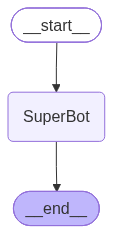

In [51]:
graph = StateGraph(State)

graph.add_node("SuperBot",superbot)
graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)

graph_builder=graph.compile(checkpointer=memory)

from IPython.display import Image,display

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [53]:
config={"configurable":{"thread_id":"1"}}
graph_builder.invoke({'messages':"hi my name is abhishek and i like cricket"},config=config)

{'messages': [HumanMessage(content='hi my name is abhishek and i like cricket', additional_kwargs={}, response_metadata={}, id='bdd9643d-9b6e-4f7b-bef0-25ad242c1ce3'),
  AIMessage(content='Hi Abhishek! It’s great to meet a fellow cricket fan. Which teams or players are you most excited about right now? Or maybe you’d like to chat about a recent match? Let me know what’s on your mind!', additional_kwargs={'reasoning_content': 'User says: "hi my name is abhishek and i like cricket". They haven\'t asked a question, but we should respond. According to policies, we can greet, ask if they want to talk about cricket. We can mention that we are a cricket fan. We should comply. No disallowed content. We can ask if they\'d like to talk about cricket, teams, players. Should be friendly.'}, response_metadata={'token_usage': {'completion_tokens': 140, 'prompt_tokens': 82, 'total_tokens': 222, 'completion_time': 0.148643671, 'completion_tokens_details': {'reasoning_tokens': 83}, 'prompt_time': 0.004

In [54]:
config={"configurable":{"thread_id":"3"}}
for chunk in graph_builder.invoke({'messages':"hi my name is abhishek and i like cricket"},config=config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hey Abhishek! 👋 Great to meet you. Cricket’s an awesome sport—do you play or just watch? Which teams or players do you follow? Let me know, and we can chat about matches, stats, or anything else you’re curious about!', additional_kwargs={'reasoning_content': 'The user says: "hi my name is abhishek and i like cricket". They are greeting, giving name, and stating interest. They might want a response. We should greet them, ask about cricket. Also mention we can talk about cricket. We should maintain friendly tone. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 125, 'prompt_tokens': 82, 'total_tokens': 207, 'completion_time': 0.132559166, 'completion_tokens_details': {'reasoning_tokens': 62}, 'prompt_time': 0.003942951, 'prompt_tokens_details': None, 'queue_time': 0.315854918, 'total_time': 0.136502117}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_d3e146e1a5', 'service_tier': 'on_demand', 'finish_

In [55]:
config={"configurable":{"thread_id":"3"}}
for chunk in graph_builder.invoke({'messages':"hi my name is abhishek and i like cricket"},config=config,stream_mode="values"):
    print(chunk)

messages


In [56]:
config={"configurable":{"thread_id":"3"}}
response= graph_builder.invoke({'messages':"hi my name is abhishek and i like cricket"},config=config,stream_mode="values")
response

{'messages': [HumanMessage(content='hi my name is abhishek and i like cricket', additional_kwargs={}, response_metadata={}, id='9a2f3ab3-0ef8-40fd-95bd-0a2348a4add7'),
  AIMessage(content='Hey Abhishek! 👋 Great to meet you. Cricket’s an awesome sport—do you play or just watch? Which teams or players do you follow? Let me know, and we can chat about matches, stats, or anything else you’re curious about!', additional_kwargs={'reasoning_content': 'The user says: "hi my name is abhishek and i like cricket". They are greeting, giving name, and stating interest. They might want a response. We should greet them, ask about cricket. Also mention we can talk about cricket. We should maintain friendly tone. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 125, 'prompt_tokens': 82, 'total_tokens': 207, 'completion_time': 0.132559166, 'completion_tokens_details': {'reasoning_tokens': 62}, 'prompt_time': 0.003942951, 'prompt_tokens_details': None, 'queue_time': 0.31585491

In [57]:
config={"configurable":{"thread_id":"4"}}
for chunk in graph_builder.invoke({'messages':"hi my name is abhishek and i like cricket"},config=config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hey Abhishek! 👋 Nice to meet you. Cricket’s a fantastic sport—do you follow any particular team or player? Or maybe you’re a fan of a specific format like Tests, ODIs, or T20s? Let me know what you’re into, and we can chat more about it!', additional_kwargs={'reasoning_content': 'User says: "hi my name is abhishek and i like cricket". They likely want a response. The assistant should respond warmly, maybe ask about cricket. The user is a beginner. Just respond.'}, response_metadata={'token_usage': {'completion_tokens': 116, 'prompt_tokens': 82, 'total_tokens': 198, 'completion_time': 0.147316586, 'completion_tokens_details': {'reasoning_tokens': 43}, 'prompt_time': 0.003948378, 'prompt_tokens_details': None, 'queue_time': 0.316769469, 'total_time': 0.151264964}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_ef00694abe', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_

In [59]:
response= graph_builder.invoke({'messages':"i also like badminton"},config=config,stream_mode="values")
response

{'messages': [HumanMessage(content='hi my name is abhishek and i like cricket', additional_kwargs={}, response_metadata={}, id='8a410878-c365-4fd5-92dd-f0bed0eb6780'),
  AIMessage(content='Hey Abhishek! 👋 Nice to meet you. Cricket’s a fantastic sport—do you follow any particular team or player? Or maybe you’re a fan of a specific format like Tests, ODIs, or T20s? Let me know what you’re into, and we can chat more about it!', additional_kwargs={'reasoning_content': 'User says: "hi my name is abhishek and i like cricket". They likely want a response. The assistant should respond warmly, maybe ask about cricket. The user is a beginner. Just respond.'}, response_metadata={'token_usage': {'completion_tokens': 116, 'prompt_tokens': 82, 'total_tokens': 198, 'completion_time': 0.147316586, 'completion_tokens_details': {'reasoning_tokens': 43}, 'prompt_time': 0.003948378, 'prompt_tokens_details': None, 'queue_time': 0.316769469, 'total_time': 0.151264964}, 'model_name': 'openai/gpt-oss-20b', 's

In [61]:
config={"configurable":{"thread_id":"5"}}
async for event in graph_builder.astream_events({'messages':"hi my name is abhishek and i like cricket"},config=config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'hi my name is abhishek and i like cricket'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a0b966-9285-7a81-b7ff-fc0096ccd334', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='hi my name is abhishek and i like cricket', additional_kwargs={}, response_metadata={}, id='2c4897cb-128f-4af4-acb0-222fc67f5221')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '01a0b966-92af-73e1-8153-ffb330e6fca9', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:f5b94c04-0f33-ce93-10b4-4851cbd6a813'}, 'parent_ids': ['01a0b966-9285-7a81-b7ff-fc0096ccd334']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMess